In [4]:
import gymnasium as gym
import numpy as np

class BlindBaselineWrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        
        # The original pc-gym observation space has 9 elements. 
        # We delete index 3 (mu3) to shrink the boundaries down to 8 elements.
        low = np.delete(self.env.observation_space.low, 3)   
        high = np.delete(self.env.observation_space.high, 3) 
        
        # Redefine the space so PPO allocates an 8-neuron input layer
        self.observation_space = gym.spaces.Box(low=low, high=high, dtype=np.float32)

    def observation(self, obs):
        # Every time the environment returns an observation during reset() or step(),
        # we drop index 3 (mu3) before the PPO agent can see it.
        return np.delete(obs, 3)

In [ ]:
import numpy as np
from pcgym import make_env

T = 30.0       
nsteps = 30    

# =====================================================================
# 1. DROP LN FROM SETPOINTS (Now len(SP) = 1)
# =====================================================================
SP = {
    'CV': [1.00 for _ in range(nsteps)],
    'Ln': [15.00 for _ in range(nsteps)]
}

action_space = {
    'low': np.array([-1.0]),   
    'high': np.array([1.0])    
}

# =====================================================================
# 2. UPDATE SPACES (7 States + 1 Setpoint = 8 Total)
# =====================================================================
# Order is now: [mu0, mu1, mu2, mu3, C, CV, Ln, CV_SP]
observation_space = {
    'low' : np.array([0.0, 0.0, 0.0, 0.0, 0.00, 0.00, 0.00, 0.00, 0.00]),
    'high' : np.array([1.0e20, 1.0e20, 1.0e20, 1.0e20, 0.50, 2.00, 20.00, 2.00, 20.00])  
}

env_params = {
    'N': nsteps, 
    'tsim': T, 
    'SP': SP, 
    'o_space': observation_space, 
    'a_space': action_space,
    
    # x0 must keep all 7 physical states + 1 initial setpoint value = 8 elements
    'x0': np.array([1.50e3, 2.30e4, 2.50e8, 0.0, 0.16, 1.00, 15.00, 1.00, 15.00]),
    
    # Remove Ln from the reward scaling since it's no longer a tracked setpoint
    'r_scale': {
        'CV': 1e1,
        'Ln': 1e0
    },
    
    'model': 'crystallization', 
    'normalise_a': True, 
    'normalise_o': True, 
    'noise': True, 
    'integration_method': 'jax', 
    'noise_percentage': 0.01, 
}

# Initialize Environment
env = make_env(env_params)
obs, info = env.reset()

print("Observation shape:", obs.shape) # Will print (8,) safely!

Observation shape: (8,)


/Users/phattharapongduangkham/Documents/pc-gym/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/phattharapongduangkham/Documents/pc-gym/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [2]:
from stable_baselines3 import PPO

nsteps_learning = 100000
PPO_policy = PPO('MlpPolicy', env, verbose=1).learn(nsteps_learning)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/Users/phattharapongduangkham/Documents/pc-gym/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/phattharapongduangkham/Documents/pc-gym/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 29        |
|    ep_rew_mean     | -1.06e+05 |
| time/              |           |
|    fps             | 90        |
|    iterations      | 1         |
|    time_elapsed    | 22        |
|    total_timesteps | 2048      |
----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 29           |
|    ep_rew_mean          | -1.06e+05    |
| time/                   |              |
|    fps                  | 88           |
|    iterations           | 2            |
|    time_elapsed         | 46           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 8.418388e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.42        |
|    explained_variance   | 4.77e-07     |
|    

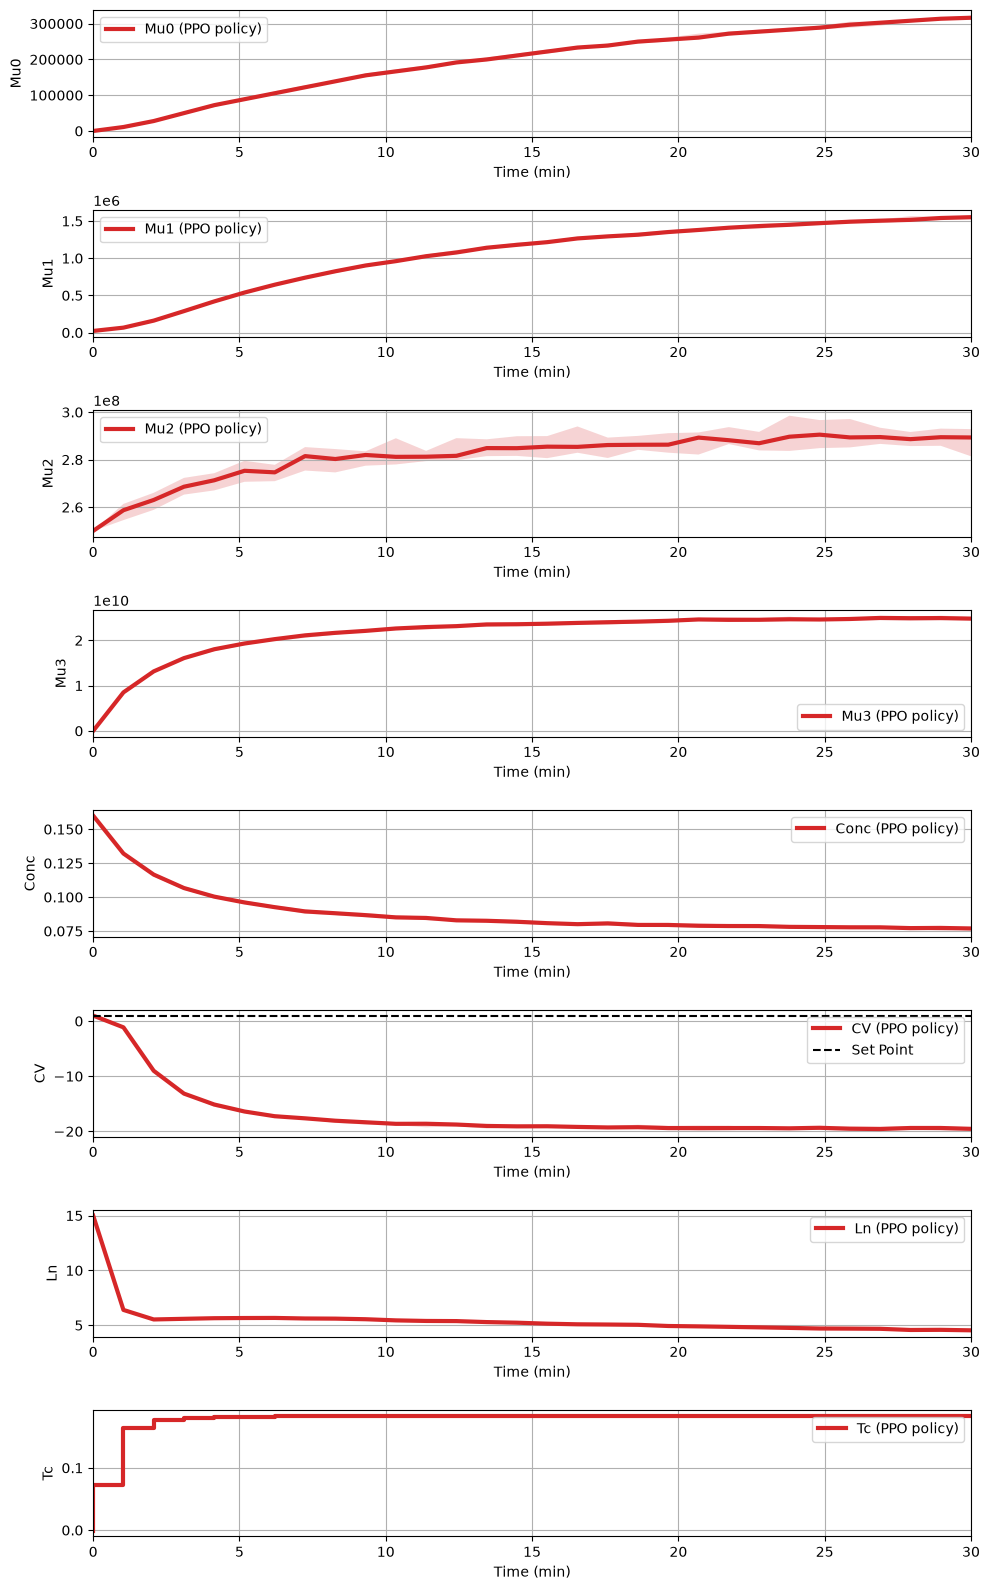

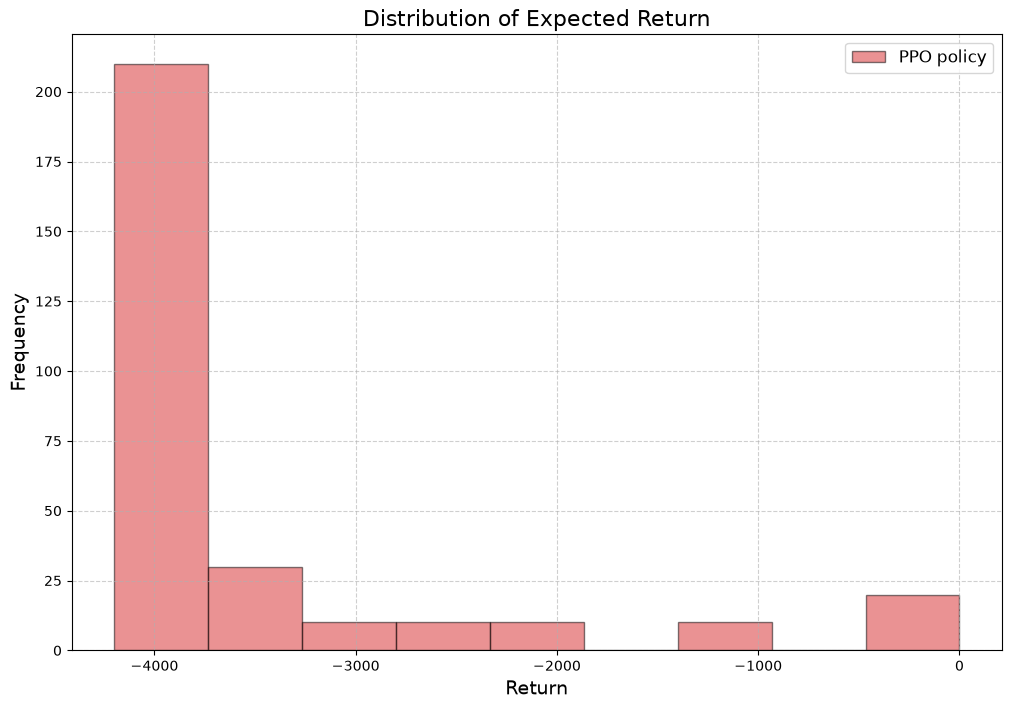

Your final score is: -3499.60 (larger the better).


In [3]:
evaluator, data = env.plot_rollout({'PPO policy':PPO_policy}, reps = 10, oracle = False, dist_reward=True) #, MPC_params={'N':10,'R':0.1}) # Rollout your policy
res = data['PPO policy']['r'].mean()
print(f"Your final score is: {res:.2f} (larger the better).")

In [5]:
obs, state = env.reset()
print("Observation Shape:", obs.shape)  # MUST print (8,)
print("Obs Space Expected Shape:", env.observation_space.shape)  # MUST print (8,)

Observation Shape: (8,)
Obs Space Expected Shape: (8,)


In [6]:
print("Nx_oracle index value:", env.Nx_oracle)
print("Length of SP tracking array:", len(env.SP))

Nx_oracle index value: 7
Length of SP tracking array: 2


In [1]:
import numpy as np
import gymnasium as gym
from pcgym import make_env
from stable_baselines3 import PPO

# =====================================================================
# 1. THE BLIND WRAPPER (Strips out mu3)
# =====================================================================
class BlindBaselineWrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        
        # The original pc-gym observation space has 9 elements. 
        # We delete index 3 (mu3) to shrink the boundaries down to 8 elements.
        low = np.delete(self.env.observation_space.low, 3)   
        high = np.delete(self.env.observation_space.high, 3) 
        
        # Redefine the space so PPO allocates an 8-neuron input layer
        self.observation_space = gym.spaces.Box(low=low, high=high, dtype=np.float32)

    def observation(self, obs):
        # Every time the environment returns an observation during reset() or step(),
        # we drop index 3 (mu3) before the PPO agent can see it.
        return np.delete(obs, 3)

# =====================================================================
# 2. STANDARD FULL 9-DIMENSIONAL ENVIRONMENT CONFIGURATION
# =====================================================================
T = 30.0       
nsteps = 30    

SP = {
    'CV': [1.00 for _ in range(nsteps)],
    'Ln': [15.00 for _ in range(nsteps)]
}

action_space = {
    'low': np.array([-1.0]),   
    'high': np.array([1.0])    
}

# Keep all 9 elements here so pc-gym doesn't throw a JAX error
observation_space = {
    'low' : np.array([0.0, 0.0, 0.0, 0.0, 0.00, 0.00, 0.00, 0.00, 0.00]),
    'high' : np.array([1.0e20, 1.0e20, 1.0e20, 1.0e20, 0.50, 2.00, 20.00, 2.00, 20.00])  
}

env_params = {
    'N': nsteps, 
    'tsim': T, 
    'SP': SP, 
    'o_space': observation_space, 
    'a_space': action_space,
    
    # Fully populated 9-element initial state vector [mu0, mu1, mu2, mu3, C, CV, Ln, CV_SP, Ln_SP]
    'x0': np.array([1.50e3, 2.30e4, 2.50e8, 0.0, 0.16, 1.00, 15.00, 1.00, 15.00]),
    
    'r_scale': {
        'CV': 1e1,
        'Ln': 1e0
    },
    
    'model': 'crystallization', 
    'normalise_a': True, 
    'normalise_o': True, 
    'noise': True, 
    'integration_method': 'jax', 
    'noise_percentage': 0.01, 
}

# =====================================================================
# 3. INITIALIZE AND TRAIN THE BLIND BASELINE
# =====================================================================
# Create the true physical environment (9 dimensions)
base_env = make_env(env_params)

# Wrap it to make it blind (Converts to 8 dimensions for the agent)
blind_env = BlindBaselineWrapper(base_env)

print("Wrapped Obs Space Shape passed to PPO:", blind_env.observation_space.shape) # Output: (8,)

# Train your policy on the blind features
PPO_blind_policy = PPO('MlpPolicy', blind_env, verbose=1)
PPO_blind_policy.learn(total_timesteps=30000)

/Users/phattharapongduangkham/Documents/crystallization-partial-drl-ml/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/phattharapongduangkham/Documents/crystallization-partial-drl-ml/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Wrapped Obs Space Shape passed to PPO: (8,)
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/Users/phattharapongduangkham/Documents/crystallization-partial-drl-ml/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/phattharapongduangkham/Documents/crystallization-partial-drl-ml/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 29        |
|    ep_rew_mean     | -1.08e+05 |
| time/              |           |
|    fps             | 93        |
|    iterations      | 1         |
|    time_elapsed    | 21        |
|    total_timesteps | 2048      |
----------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 29            |
|    ep_rew_mean          | -1.09e+05     |
| time/                   |               |
|    fps                  | 91            |
|    iterations           | 2             |
|    time_elapsed         | 44            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 4.5376946e-06 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.42         |
|    explained_variance   | -4.77e

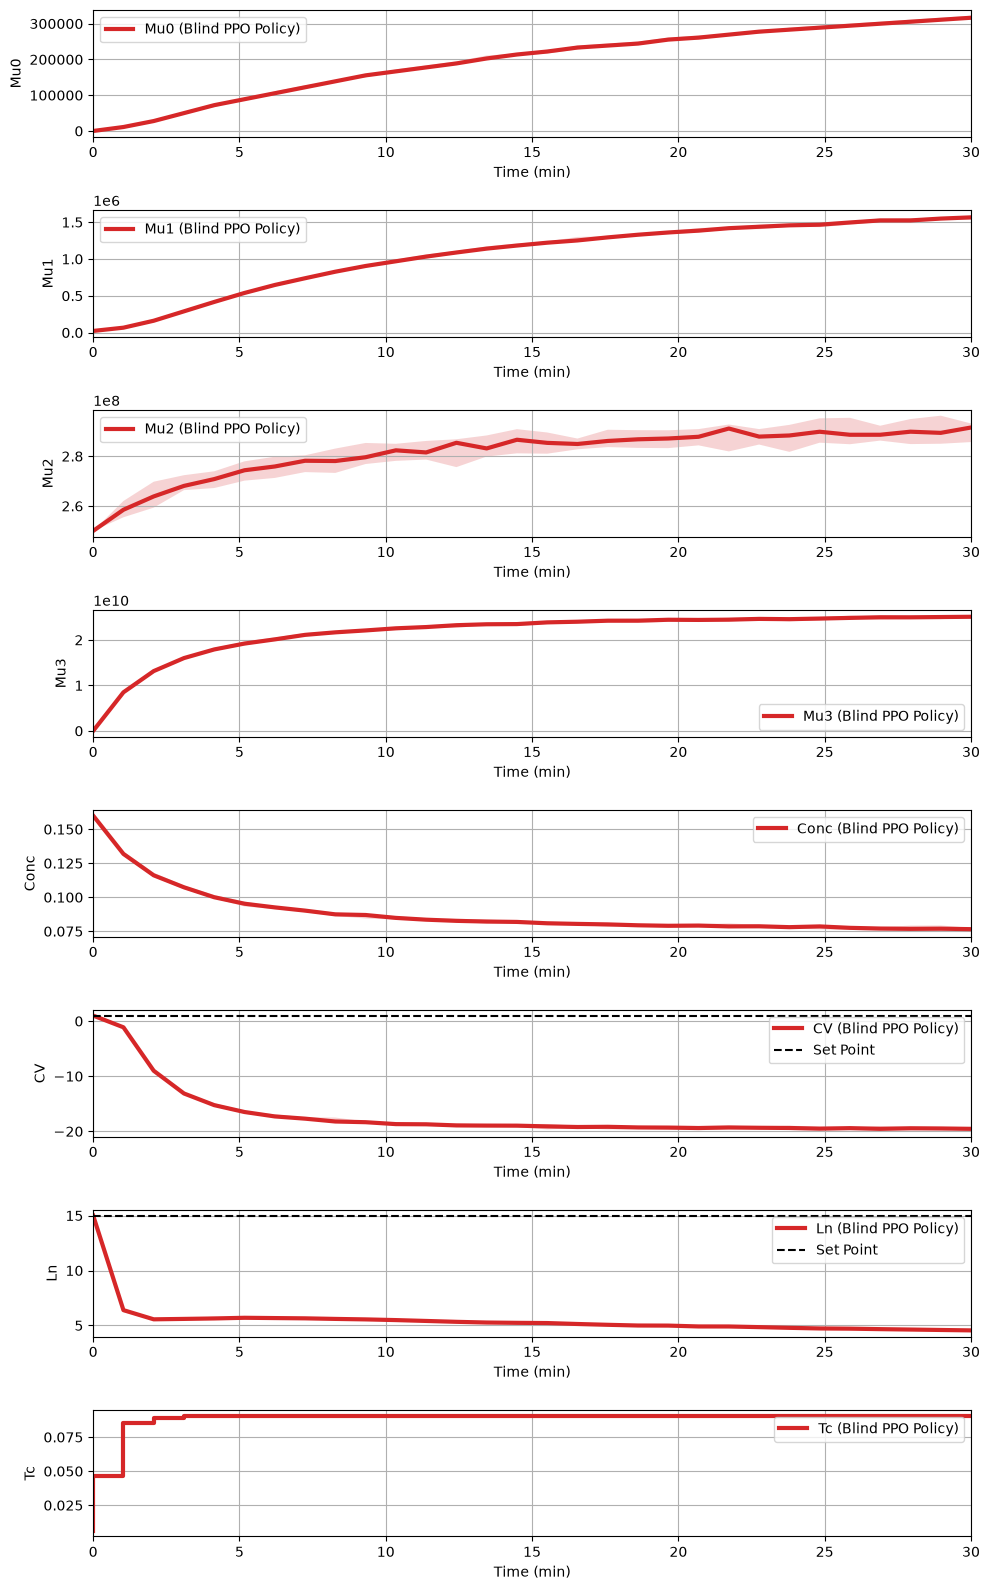

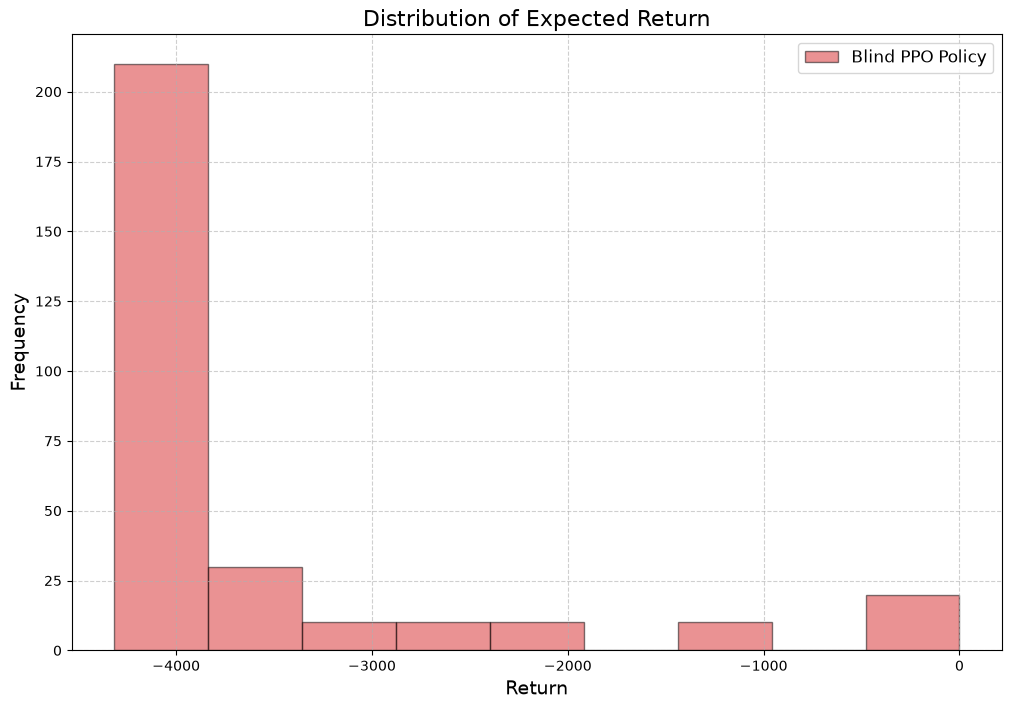

Your blind baseline final score is: -3598.71 (larger the better).


In [4]:
# =====================================================================
# DUMMY POLICY BRIDGE FOR EVALUATION
# =====================================================================
class BlindPolicyEvaluator:
    def __init__(self, trained_ppo_policy):
        self.policy = trained_ppo_policy

    def predict(self, obs, state=None, episode_start=None, deterministic=True):
        # 1. Slice out mu3 (index 3) from the 9-dimensional evaluation observation
        if len(obs.shape) > 1:
            # Handle vectorized environments / batches
            blind_obs = np.delete(obs, 3, axis=1)
        else:
            blind_obs = np.delete(obs, 3)
            
        # 2. Pass the clean 8-dimensional observation to your trained PPO policy
        return self.policy.predict(blind_obs, state, episode_start, deterministic)

# =====================================================================
# RUN THE EVALUATION
# =====================================================================
# Instantiate the evaluation bridge
evaluation_ready_policy = BlindPolicyEvaluator(PPO_blind_policy)

# Pass the wrapped policy to the BASE environment's plot_rollout tool
evaluator, data = base_env.plot_rollout(
    {'Blind PPO Policy': evaluation_ready_policy}, 
    reps=10, 
    oracle=False, 
    dist_reward=True
)

# Extract and print the final average score
res = data['Blind PPO Policy']['r'].mean()
print(f"Your blind baseline final score is: {res:.2f} (larger the better).")